## 16. DBFNet + Data Augmentation (Gaussian Noise)

### Contexto

Con datasets clínicos pequeños como PC-GITA, el sobreajuste es un problema recurrente: el modelo aprende patrones específicos de los sujetos de entrenamiento que no generalizan a sujetos nuevos. Esto se manifiesta como una diferencia entre el rendimiento en validación cruzada interna y el rendimiento en un test independiente por sujeto.

El **data augmentation** busca mitigar este problema generando muestras sintéticas que introduzcan variabilidad controlada, sin alterar las propiedades clínicas relevantes de la señal. En tareas de diadococinesia (DDK), las propiedades motor-articulatorias — tasa de repetición silábica, regularidad temporal, transiciones consonante-vocal — son el biomarcador central, por lo que cualquier técnica de aumento debe preservarlas estrictamente.

### Hipótesis

- **H1 (Baseline):** El modelo con embeddings congelados obtiene buen rendimiento en validación interna, pero su rendimiento cae en un test independiente por sujeto, evidenciando sobreajuste.

- **H2 (Augmentation):** Un aumento de datos moderado y fisiológicamente plausible (ruido gaussiano aditivo a dos niveles de SNR) mejora la sensibilidad y el accuracy del modelo, reduciendo la brecha entre validación interna y test independiente.

### Diseño experimental

- **Técnica:** Ruido gaussiano aditivo a SNR 25 dB y 20 dB (2 variantes por sujeto).
- **Aplicación:** Solo sobre el conjunto de entrenamiento (80%). El test holdout (20%) permanece intacto con grabaciones originales.
- **Validación:** Subject-independent (GroupKFold). Todas las muestras de un sujeto (original + sintéticas) permanecen en el mismo fold.
- **Comparación:** Métricas CV y test con vs. sin augmentation, usando los mismos hiperparámetros óptimos del baseline.

In [1]:
import torch
import numpy as np

TARGET_SR = 16_000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5
TEST_SIZE = 0.20
N_AUG = 1
SNR_LEVELS = [25]
VTLP_ALPHA_RANGE = (0.95, 1.05)

%load_ext autoreload
%autoreload 2

### Preprocesamiento

Carga de metadata y waveforms. Se aplica el mismo preprocesamiento que en el baseline para garantizar comparabilidad: recorte de silencios, normalización de amplitud y remuestreo a 16 kHz.

In [2]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

# Extraer subject_id del filename para augmentation
df_metadata = df_metadata.with_columns(
    df_metadata["filename"].str.replace("_pataka.wav", "").alias("subject_id")
)

print(f"Sujetos: {df_metadata['subject_id'].n_unique()}")
print(f"Grabaciones: {len(waveforms_processed)}")
print(f"Distribución: {df_metadata['label'].value_counts()}")

/Users/napster/Documents/upm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sujetos: 100
Grabaciones: 100
Distribución: shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i64   ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 50    │
│ 0     ┆ 50    │
└───────┴───────┘


### Holdout split a nivel de sujeto

Se reserva un 20% de los sujetos como test independiente. Este conjunto **nunca se aumenta** y solo contiene grabaciones originales. El 80% restante se usa para entrenamiento con cross-validation y es el único donde se aplica data augmentation.

La partición se realiza a nivel de sujeto (no de grabación) para garantizar independencia total entre train y test.

In [3]:
from sklearn.model_selection import train_test_split

labels_all = df_metadata["label"].to_numpy()
subject_ids = df_metadata["subject_id"].to_list()

# Split por sujeto, estratificado por label
train_idx, test_idx = train_test_split(
    np.arange(len(labels_all)),
    test_size=TEST_SIZE,
    stratify=labels_all,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(train_idx)} sujetos | PD={labels_all[train_idx].sum()}, HC={len(train_idx) - labels_all[train_idx].sum()}")
print(f"Test:  {len(test_idx)} sujetos  | PD={labels_all[test_idx].sum()}, HC={len(test_idx) - labels_all[test_idx].sum()}")

Train: 80 sujetos | PD=40, HC=40
Test:  20 sujetos  | PD=10, HC=10


### Data Augmentation — Ruido Gaussiano Aditivo

#### Fundamento matemático

Dado un waveform original $x(t)$, la señal aumentada se construye como:

$$\tilde{x}(t) = x(t) + \eta(t), \quad \eta(t) \sim \mathcal{N}(0, \sigma^2)$$

donde la desviación estándar del ruido $\sigma$ se determina a partir de la relación señal-ruido (SNR) deseada:

$$\text{SNR}_{\text{dB}} = 10 \cdot \log_{10} \left( \frac{P_x}{P_\eta} \right) \implies \sigma = \sqrt{\frac{P_x}{10^{\text{SNR}_{\text{dB}}/10}}}$$

siendo $P_x = \frac{1}{N}\sum_{t=1}^{N} x(t)^2$ la potencia de la señal original.

#### ¿Por qué es adecuado para DDK?

- **Preserva la estructura temporal:** la tasa de repetición silábica, las transiciones consonante-vocal y la regularidad rítmica permanecen intactas. El ruido es independiente de la señal.
- **Preserva la coherencia fisiológica:** no modifica F0, formantes ni duración. Los biomarcadores motor-articulatorios de la diadococinesia quedan inalterados.
- **Simula variabilidad real:** modela diferencias en condiciones de grabación (ruido ambiental, micrófono), que es la fuente de varianza más natural entre sesiones clínicas.
- **SNR 25 dB:** perturbación suave, apenas perceptible.
- **SNR 20 dB:** perturbación moderada, equivalente a una sala con ruido de fondo ligero.

In [4]:
def augment_waveform_noise(waveform: np.ndarray, snr_db: float, rng: np.random.Generator) -> np.ndarray:
    """
    Añade ruido gaussiano aditivo a un waveform con un SNR objetivo.

    x̃(t) = x(t) + η(t),  η ~ N(0, σ²)
    σ = sqrt(Px / 10^(SNR_dB/10))
    """
    power_signal = np.mean(waveform ** 2)
    power_noise = power_signal / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(power_noise), size=waveform.shape)
    return waveform + noise


# --- Generar waveforms aumentados solo para train ---
rng = np.random.default_rng(RANDOM_STATE)

waveforms_aug = []
labels_aug = []
subject_ids_aug = []

for idx in train_idx:
    for snr in SNR_LEVELS:
        wf_aug = augment_waveform_noise(waveforms_processed[idx], snr_db=snr, rng=rng)
        waveforms_aug.append(wf_aug)
        labels_aug.append(labels_all[idx])
        subject_ids_aug.append(subject_ids[idx])

print(f"Muestras aumentadas generadas: {len(waveforms_aug)}")
print(f"  PD: {sum(labels_aug[:len(labels_aug)] == np.array([1]*len(labels_aug)))}")
print(f"  HC: {sum(labels_aug[:len(labels_aug)] == np.array([0]*len(labels_aug)))}")
print(f"SNR aplicados: {SNR_LEVELS} dB")

Muestras aumentadas generadas: 80
  PD: 40
  HC: 40
SNR aplicados: [25] dB


### Data Augmentation — VTLP (Vocal Tract Length Perturbation)

Segunda técnica de augmentation. A diferencia del ruido gaussiano, VTLP altera el contenido espectral (formantes) sin modificar la estructura temporal. Esto genera embeddings wav2vec2 genuinamente diferentes.

**Nota:** Esta celda sobreescribe `waveforms_aug`, `labels_aug` y `subject_ids_aug`. Para volver a Gaussian Noise, re-ejecutar la celda 7 y saltar esta.

In [5]:
def vtlp_warp(waveform: np.ndarray, sr: int, alpha: float,
              n_fft: int = 512, hop_length: int = 128, f0_hz: float = 4800.0) -> np.ndarray:
    """
    Vocal Tract Length Perturbation via warping frecuencial en STFT.
    """
    stft = np.fft.rfft(
        np.lib.stride_tricks.sliding_window_view(
            np.pad(waveform, (n_fft // 2, n_fft // 2), mode="reflect"),
            n_fft
        )[::hop_length] * np.hanning(n_fft)
    )

    n_frames, n_bins = stft.shape
    freqs = np.linspace(0, sr / 2, n_bins)
    f_max = sr / 2

    warped_freqs = np.where(
        freqs <= f0_hz,
        alpha * freqs,
        ((f_max - alpha * f0_hz) / (f_max - f0_hz)) * (freqs - f0_hz) + alpha * f0_hz
    )

    stft_warped = np.zeros_like(stft)
    for t in range(n_frames):
        mag = np.abs(stft[t])
        phase = np.angle(stft[t])
        stft_warped[t] = np.interp(freqs, warped_freqs, mag) * \
                         np.exp(1j * np.interp(freqs, warped_freqs, phase))

    output_len = len(waveform)
    result = np.zeros(output_len + n_fft)
    window = np.hanning(n_fft)
    norm = np.zeros_like(result)

    for t in range(n_frames):
        start = t * hop_length
        result[start:start + n_fft] += np.fft.irfft(stft_warped[t], n=n_fft) * window
        norm[start:start + n_fft] += window ** 2

    result /= np.maximum(norm, 1e-8)
    return result[n_fft // 2: n_fft // 2 + output_len]


# --- Sobreescribe las variables de augmentation con VTLP ---
rng = np.random.default_rng(RANDOM_STATE)

waveforms_aug = []
labels_aug = []
subject_ids_aug = []

for idx in train_idx:
    alpha = rng.uniform(*VTLP_ALPHA_RANGE)
    wf_aug = vtlp_warp(waveforms_processed[idx], sr=TARGET_SR, alpha=alpha)
    waveforms_aug.append(wf_aug)
    labels_aug.append(labels_all[idx])
    subject_ids_aug.append(subject_ids[idx])
    print(f"  {subject_ids[idx]}: α={alpha:.4f}")

print(f"\nMuestras aumentadas (VTLP): {len(waveforms_aug)}")

  AVPEPUDEAC0018: α=1.0274
  AVPEPUDEA0003: α=0.9939
  AVPEPUDEA0013: α=1.0359
  AVPEPUDEA0021: α=1.0197
  AVPEPUDEA0023: α=0.9594
  AVPEPUDEAC0008: α=1.0476
  AVPEPUDEAC0035: α=1.0261
  AVPEPUDEA0011: α=1.0286
  AVPEPUDEAC0052: α=0.9628
  AVPEPUDEA0059: α=0.9950
  AVPEPUDEAC0040: α=0.9871
  AVPEPUDEAC0041: α=1.0427
  AVPEPUDEA0046: α=1.0144
  AVPEPUDEA0035: α=1.0323
  AVPEPUDEA0049: α=0.9943
  AVPEPUDEAC0047: α=0.9727
  AVPEPUDEA0038: α=1.0055
  AVPEPUDEAC0004: α=0.9564
  AVPEPUDEAC0015: α=1.0328
  AVPEPUDEA0030: α=1.0132
  AVPEPUDEA0014: α=1.0258
  AVPEPUDEAC0054: α=0.9855
  AVPEPUDEAC0012: α=1.0471
  AVPEPUDEAC0033: α=1.0393
  AVPEPUDEAC0022: α=1.0278
  AVPEPUDEAC0045: α=0.9695
  AVPEPUDEA0025: α=0.9967
  AVPEPUDEAC0053: α=0.9544
  AVPEPUDEA0026: α=0.9654
  AVPEPUDEA0022: α=1.0183
  AVPEPUDEA0047: α=1.0245
  AVPEPUDEA0006: α=1.0468
  AVPEPUDEAC0039: α=0.9826
  AVPEPUDEA0032: α=0.9870
  AVPEPUDEA0050: α=0.9970
  AVPEPUDEAC0007: α=0.9689
  AVPEPUDEAC0051: α=0.9630
  AVPEPUDEA0020: α=0

### Verificación visual del augmentation

Comparación de un waveform original con sus dos variantes aumentadas (SNR 25 dB y 20 dB). La estructura temporal — ciclos de repetición silábica /pa-ta-ka/ — debe permanecer visualmente idéntica, con solo una ligera adición de ruido de fondo.

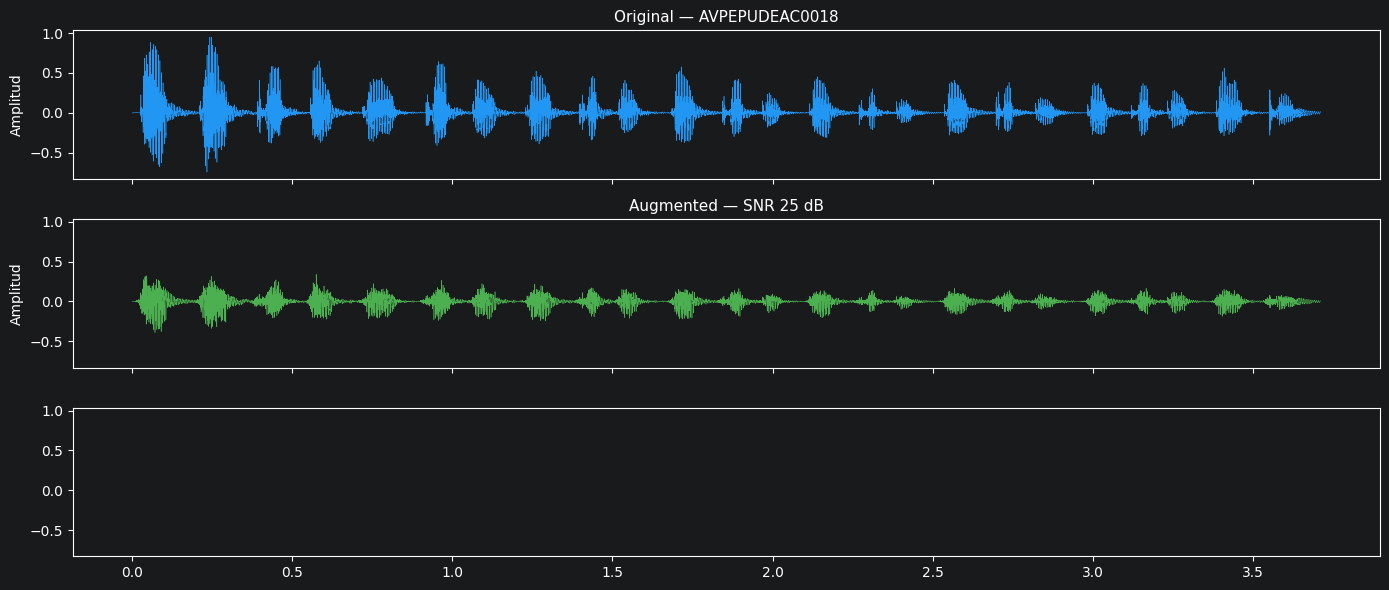

In [6]:
import matplotlib.pyplot as plt

# Tomar el primer sujeto de train como ejemplo
example_idx = train_idx[0]
example_original = waveforms_processed[example_idx]
example_aug_25 = waveforms_aug[0]  # primera variante (SNR 25 dB)
example_aug_20 = waveforms_aug[1]  # segunda variante (SNR 20 dB)

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True, sharey=True)
time_axis = np.arange(len(example_original)) / TARGET_SR

axes[0].plot(time_axis, example_original, linewidth=0.4, color="#2196F3")
axes[0].set_title(f"Original — {subject_ids[example_idx]}", fontsize=11)
axes[0].set_ylabel("Amplitud")

axes[1].plot(time_axis, example_aug_25, linewidth=0.4, color="#4CAF50")
axes[1].set_title("Augmented — SNR 25 dB", fontsize=11)
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

### Extracción de embeddings

Se extraen embeddings wav2vec2 (capa 0) y features espectrales de ResNet sobre **todas** las waveforms:

In [7]:
from src.embeddings import extract_multilayer_embeddings

# Construir lista ordenada de waveforms: train originales + augmentadas + test originales
waveforms_train_orig = [waveforms_processed[i] for i in train_idx]
waveforms_test_orig = [waveforms_processed[i] for i in test_idx]

waveforms_all = waveforms_train_orig + waveforms_aug + waveforms_test_orig

# Extraer embeddings wav2vec2 capa 0
w2v_layers = extract_multilayer_embeddings(
    waveforms_all, "facebook/wav2vec2-base", [0], DEVICE
)
emb_w2v_L0 = w2v_layers[0]

n_train_orig = len(train_idx)
n_aug = len(waveforms_aug)
n_test = len(test_idx)

print(f"Embeddings extraídos: {len(emb_w2v_L0)}")
print(f"  Train originales: {n_train_orig}")
print(f"  Augmentadas: {n_aug}")
print(f"  Test originales: {n_test}")

2026-04-12 20:08:25,749 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-04-12 20:08:26,364 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-12 20:08:26,603 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-12 20:08:26,821 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-12 20:08:26,822 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-12 20:08:27,023 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-12 20:08:27,224 [INFO

  25/180


2026-04-12 20:08:29,848 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/refs%2Fpr%2F11/model.safetensors "HTTP/1.1 302 Found"


  50/180
  75/180
  100/180
  125/180
  150/180
  175/180
Embeddings extraídos: 180
  Train originales: 80
  Augmentadas: 80
  Test originales: 20


### Features espectrales de ResNet

In [8]:
from src.spectral import extract_spectral_features

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 128,
}

spectral_features = extract_spectral_features(
    waveforms_all, device=DEVICE, **MEL_CONFIG
)

print(f"Spectral features extraídos: {len(spectral_features)}")

2026-04-12 20:08:34,924 [INFO] src.config: Generando mel-espectrogramas...
2026-04-12 20:08:35,005 [INFO] src.config:   180 espectrogramas generados
2026-04-12 20:08:35,005 [INFO] src.config:   Shape ejemplo: (128, 117)
2026-04-12 20:08:35,006 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-04-12 20:08:35,429 [INFO] src.config:   25/180
2026-04-12 20:08:35,496 [INFO] src.config:   50/180
2026-04-12 20:08:35,566 [INFO] src.config:   75/180
2026-04-12 20:08:35,630 [INFO] src.config:   100/180
2026-04-12 20:08:35,695 [INFO] src.config:   125/180
2026-04-12 20:08:35,776 [INFO] src.config:   150/180
2026-04-12 20:08:35,842 [INFO] src.config:   175/180
2026-04-12 20:08:35,856 [INFO] src.config:   Features espectrales: (180, 512)


Spectral features extraídos: 180


### Normalización y preparación de datos

Se ajusta el StandardScaler **solo con las muestras de entrenamiento** (originales + aumentadas) y se transforma test con esos mismos parámetros. Esto evita data leakage del test hacia el scaler.

Se construyen los arrays de labels y subject_ids manteniendo el mismo orden: train originales → augmentadas → test originales.

In [9]:
from sklearn.preprocessing import StandardScaler

# --- Separar embeddings por partición ---
emb_t_train = emb_w2v_L0[:n_train_orig + n_aug]
emb_t_test = emb_w2v_L0[n_train_orig + n_aug:]

emb_s_train = spectral_features[:n_train_orig + n_aug]
emb_s_test = spectral_features[n_train_orig + n_aug:]

# --- Labels y subject_ids para train (originales + augmentadas) ---
labels_train_orig = labels_all[train_idx]
subject_ids_train_orig = [subject_ids[i] for i in train_idx]

labels_train = np.concatenate([labels_train_orig, np.array(labels_aug)])
subject_ids_train = subject_ids_train_orig + subject_ids_aug

# --- Labels para test ---
labels_test = labels_all[test_idx]

# --- Normalización: fit en train, transform en ambos ---
scaler_t = StandardScaler()
scaler_s = StandardScaler()

emb_t_train = scaler_t.fit_transform(emb_t_train)
emb_t_test = scaler_t.transform(emb_t_test)

emb_s_train = scaler_s.fit_transform(emb_s_train)
emb_s_test = scaler_s.transform(emb_s_test)

print(f"Train: {len(labels_train)} muestras ({n_train_orig} orig + {n_aug} aug)")
print(f"  PD: {labels_train.sum():.0f} | HC: {len(labels_train) - labels_train.sum():.0f}")
print(f"Test: {len(labels_test)} muestras (solo originales)")
print(f"  PD: {labels_test.sum()} | HC: {len(labels_test) - labels_test.sum()}")
print(f"Subject IDs train (únicos): {len(set(subject_ids_train))}")

Train: 160 muestras (80 orig + 80 aug)
  PD: 80 | HC: 80
Test: 20 muestras (solo originales)
  PD: 10 | HC: 10
Subject IDs train (únicos): 80


### Cross-validation subject sin augmentation

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

# --- Solo muestras originales de train ---
emb_t_train_orig = emb_t_train[:n_train_orig]
emb_s_train_orig = emb_s_train[:n_train_orig]

bp = {
    "lr": 0.00012786728092781501,
    "weight_decay": 0.0015780942840282076,
    "dropout": 0.45,
    "label_smoothing": 0.05,
    "batch_size": 32,
    "dim_proj": 128,
    "dim_hidden": 128,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

bl_aucs, bl_accs, bl_sens, bl_spec = [], [], [], []
bl_histories = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train_orig, labels_train_orig)):

    train_ds = DualBranchDataset(emb_t_train_orig, emb_s_train_orig, labels_train_orig, tr_idx)
    val_ds = DualBranchDataset(emb_t_train_orig, emb_s_train_orig, labels_train_orig, val_idx)

    y_true, y_prob, alphas, history = train_fold_regularized(
        train_ds, val_ds, DEVICE, **bp
    )

    auc = roc_auc_score(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]

    bl_aucs.append(auc)
    bl_accs.append(acc)
    bl_sens.append(sens)
    bl_spec.append(spec)
    bl_histories.append(history)

    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nBaseline CV: AUC={np.mean(bl_aucs):.3f}±{np.std(bl_aucs):.3f} | "
      f"Acc={np.mean(bl_accs):.3f}±{np.std(bl_accs):.3f} | "
      f"Sens={np.mean(bl_sens):.3f}±{np.std(bl_sens):.3f} | "
      f"Spec={np.mean(bl_spec):.3f}±{np.std(bl_spec):.3f}")

Fold 1: AUC=0.922 | Acc=0.875 | Sens=0.875 | Spec=1.000
Fold 2: AUC=0.812 | Acc=0.750 | Sens=0.625 | Spec=0.875
Fold 3: AUC=0.938 | Acc=0.875 | Sens=0.750 | Spec=1.000
Fold 4: AUC=0.891 | Acc=0.812 | Sens=0.625 | Spec=1.000
Fold 5: AUC=0.859 | Acc=0.688 | Sens=0.750 | Spec=0.875

Baseline CV: AUC=0.884±0.045 | Acc=0.800±0.073 | Sens=0.725±0.094 | Spec=0.950±0.061


### Cross-validation subject-independent con augmentation

Se utiliza `GroupKFold` con `subject_id` como variable de agrupación. Esto garantiza que **todas las muestras de un mismo sujeto** (la original y sus 2 variantes aumentadas) caen en el mismo fold, cumpliendo el requisito de validación subject-independent.

In [11]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

bp = {
    "lr": 0.00012786728092781501,
    "weight_decay": 0.0015780942840282076,
    "dropout": 0.45,
    "label_smoothing": 0.05,
    "batch_size": 32,
    "dim_proj": 128,
    "dim_hidden": 128,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}

groups_train = np.array(subject_ids_train)
gkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []
all_histories = []

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(emb_t_train, labels_train, groups_train)):

    # Validación solo con muestras originales
    val_idx_orig = [i for i in val_idx if i < n_train_orig]

    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, tr_idx)
    val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx_orig)

    y_true, y_prob, alphas, history = train_fold_regularized(
        train_ds, val_ds, DEVICE, **bp
    )

    auc = roc_auc_score(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_sens.append(sens)
    fold_spec.append(spec)
    all_histories.append(history)

    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nMedia CV: AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f} | "
      f"Acc={np.mean(fold_accs):.3f}±{np.std(fold_accs):.3f} | "
      f"Sens={np.mean(fold_sens):.3f}±{np.std(fold_sens):.3f} | "
      f"Spec={np.mean(fold_spec):.3f}±{np.std(fold_spec):.3f}")

Fold 1: AUC=1.000 | Acc=0.938 | Sens=0.875 | Spec=1.000
Fold 2: AUC=0.875 | Acc=0.750 | Sens=0.750 | Spec=0.875
Fold 3: AUC=0.938 | Acc=0.812 | Sens=0.875 | Spec=1.000
Fold 4: AUC=0.922 | Acc=0.875 | Sens=0.875 | Spec=1.000
Fold 5: AUC=0.766 | Acc=0.750 | Sens=0.500 | Spec=1.000

Media CV: AUC=0.900±0.078 | Acc=0.825±0.073 | Sens=0.775±0.146 | Spec=0.975±0.050


### Resultados de Cross-Validation con Augmentation

Métricas por fold y promedio. Se compararán con el baseline al final del notebook.

In [12]:
import pandas as pd

df_cv_aug = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(N_FOLDS)] + ["Media", "Std"],
    "AUC": fold_aucs + [np.mean(fold_aucs), np.std(fold_aucs)],
    "Accuracy": fold_accs + [np.mean(fold_accs), np.std(fold_accs)],
    "Sensibilidad": fold_sens + [np.mean(fold_sens), np.std(fold_sens)],
    "Especificidad": fold_spec + [np.mean(fold_spec), np.std(fold_spec)],
})

df_cv_aug = df_cv_aug.round(3)
df_cv_aug

,Fold,AUC,Accuracy,Sensibilidad,Especificidad
0,Fold 1,1.000,0.938,0.875,1.000
1,Fold 2,0.875,0.750,0.750,0.875
2,Fold 3,0.938,0.812,0.875,1.000
3,Fold 4,0.922,0.875,0.875,1.000
4,Fold 5,0.766,0.750,0.500,1.000
5,Media,0.900,0.825,0.775,0.975
6,Std,0.078,0.073,0.146,0.050


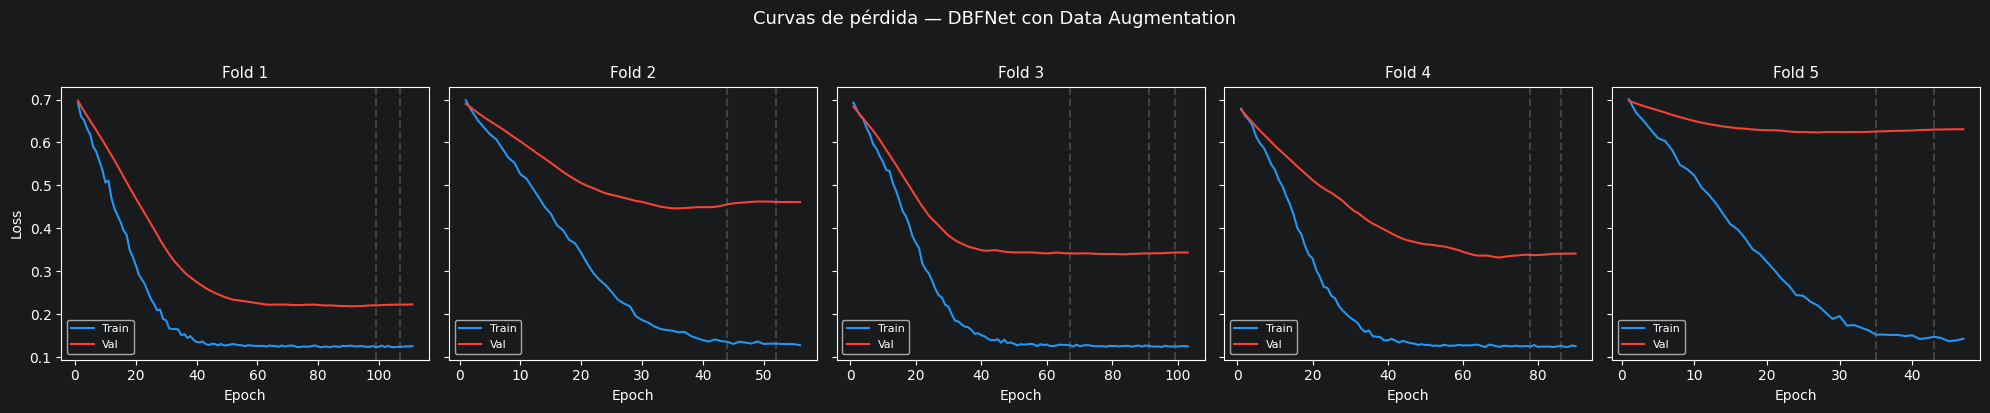

In [13]:
fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, all_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", linewidth=1.5, color="#2196F3")
    ax.plot(epochs, hist["val_loss"],   label="Val",   linewidth=1.5, color="#F44336")

    for j, lr_val in enumerate(hist["lr"]):
        if j > 0 and lr_val < hist["lr"][j-1]:
            ax.axvline(j+1, color="gray", linestyle="--", alpha=0.4)

    ax.set_title(f"Fold {i+1}", fontsize=11)
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

plt.suptitle("Curvas de pérdida — DBFNet con Data Augmentation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
train_ds_final = DualBranchDataset(
    emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train))
)
test_ds_final = DualBranchDataset(
    emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test))
)

N_SEEDS = 5
test_probs = []

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_true, y_prob, alphas, _ = train_fold_regularized(
        train_ds_final, test_ds_final, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=bp["epochs"],
        patience=bp["patience"], scheduler_factor=bp["scheduler_factor"],
        scheduler_patience=bp["scheduler_patience"],
    )
    test_probs.append(y_prob)
    print(f"Seed {seed}: AUC={roc_auc_score(y_true, y_prob):.3f}")

# Promedio de probabilidades sobre seeds
y_prob_avg = np.mean(test_probs, axis=0)
y_pred_avg = (y_prob_avg >= 0.5).astype(int)

auc_test = roc_auc_score(y_true, y_prob_avg)
acc_test = accuracy_score(y_true, y_pred_avg)
sens_test = recall_score(y_true, y_pred_avg, pos_label=1)
fpr, tpr, _ = roc_curve(y_true, y_prob_avg)
spec_test = 1 - fpr[np.argmax(tpr - fpr)]

print(f"\nTest Holdout (ensemble {N_SEEDS} seeds):")
print(f"  AUC:           {auc_test:.3f}")
print(f"  Accuracy:      {acc_test:.3f}")
print(f"  Sensibilidad:  {sens_test:.3f}")
print(f"  Especificidad: {spec_test:.3f}")

Seed 0: AUC=0.800
Seed 1: AUC=0.790
Seed 2: AUC=0.770
Seed 3: AUC=0.780
Seed 4: AUC=0.800

Test Holdout (ensemble 5 seeds):
  AUC:           0.800
  Accuracy:      0.600
  Sensibilidad:  0.600
  Especificidad: 1.000


### Evaluación en test holdout: Baseline vs. Augmentation

Se entrenan dos modelos con todos los datos de train y se evalúan sobre el mismo test holdout (20%, solo originales):
- **Baseline:** entrenado solo con originales
- **Augmented:** entrenado con originales + aumentadas

Se repite con 5 seeds para estabilidad.

In [15]:
N_SEEDS = 5

# === BASELINE (solo originales) ===
emb_t_train_orig = emb_t_train[:n_train_orig]
emb_s_train_orig = emb_s_train[:n_train_orig]

bl_test_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_ds = DualBranchDataset(emb_t_train_orig, emb_s_train_orig, labels_train_orig, np.arange(n_train_orig))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))

    y_true, y_prob, _, _ = train_fold_regularized(train_ds, test_ds, DEVICE, **bp)
    bl_test_probs.append(y_prob)

bl_prob_avg = np.mean(bl_test_probs, axis=0)
bl_pred_avg = (bl_prob_avg >= 0.5).astype(int)

# === AUGMENTED (originales + aumentadas) ===
aug_test_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))

    y_true, y_prob, _, _ = train_fold_regularized(train_ds, test_ds, DEVICE, **bp)
    aug_test_probs.append(y_prob)

aug_prob_avg = np.mean(aug_test_probs, axis=0)
aug_pred_avg = (aug_prob_avg >= 0.5).astype(int)

# === Métricas ===
def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

bl_metrics = compute_metrics(y_true, bl_prob_avg, bl_pred_avg)
aug_metrics = compute_metrics(y_true, aug_prob_avg, aug_pred_avg)

print("Test Holdout (ensemble 5 seeds):")
print(f"  {'Métrica':<15} {'Baseline':>10} {'Augmented':>10} {'Δ':>10}")
print(f"  {'─'*45}")
for name, bl, aug in zip(["AUC","Accuracy","Sensibilidad","Especificidad"], bl_metrics, aug_metrics):
    print(f"  {name:<15} {bl:>10.3f} {aug:>10.3f} {aug-bl:>+10.3f}")

Test Holdout (ensemble 5 seeds):
  Métrica           Baseline  Augmented          Δ
  ─────────────────────────────────────────────
  AUC                  0.830      0.800     -0.030
  Accuracy             0.650      0.600     -0.050
  Sensibilidad         0.600      0.600     +0.000
  Especificidad        1.000      1.000     +0.000


### Comparación visual: Baseline vs. Augmentation

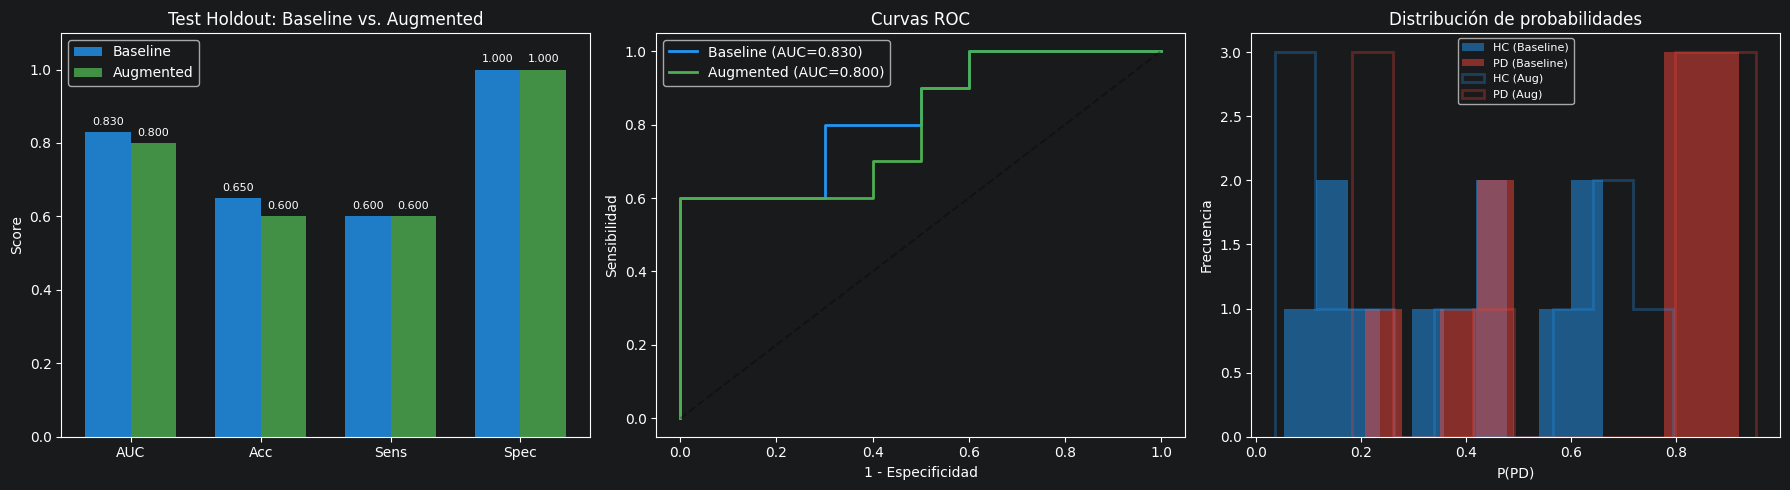

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Barras de métricas ---
ax = axes[0]
metrics_names = ["AUC", "Acc", "Sens", "Spec"]
x = np.arange(len(metrics_names))
width = 0.35

bars_bl = ax.bar(x - width/2, bl_metrics, width, label="Baseline", color="#2196F3", alpha=0.8)
bars_aug = ax.bar(x + width/2, aug_metrics, width, label="Augmented", color="#4CAF50", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Test Holdout: Baseline vs. Augmented")
ax.legend()

for bar in bars_bl:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars_aug:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

# --- 2. Curvas ROC ---
ax = axes[1]
fpr_bl, tpr_bl, _ = roc_curve(y_true, bl_prob_avg)
fpr_aug, tpr_aug, _ = roc_curve(y_true, aug_prob_avg)

ax.plot(fpr_bl, tpr_bl, color="#2196F3", linewidth=2, label=f"Baseline (AUC={bl_metrics[0]:.3f})")
ax.plot(fpr_aug, tpr_aug, color="#4CAF50", linewidth=2, label=f"Augmented (AUC={aug_metrics[0]:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_title("Curvas ROC")
ax.legend()

# --- 3. Distribución de probabilidades ---
ax = axes[2]
ax.hist(bl_prob_avg[y_true == 0], bins=10, alpha=0.5, color="#2196F3", label="HC (Baseline)")
ax.hist(bl_prob_avg[y_true == 1], bins=10, alpha=0.5, color="#F44336", label="PD (Baseline)")
ax.hist(aug_prob_avg[y_true == 0], bins=10, alpha=0.3, color="#2196F3", edgecolor="#2196F3", linewidth=2, histtype="step", label="HC (Aug)")
ax.hist(aug_prob_avg[y_true == 1], bins=10, alpha=0.3, color="#F44336", edgecolor="#F44336", linewidth=2, histtype="step", label="PD (Aug)")
ax.set_xlabel("P(PD)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Data Augmentation — Manifold Mixup intra-clase

Tercera estrategia: en vez de perturbar waveforms, se interpolan embeddings de sujetos de la misma clase dentro de cada fold de entrenamiento.

$$\tilde{z} = \lambda \cdot z_i + (1 - \lambda) \cdot z_j, \quad \lambda \sim \text{Beta}(0.4, 0.4)$$

Esto genera diversidad directamente en el espacio de representación donde opera el clasificador, sin pasar por el encoder wav2vec2 (que ya absorbe variabilidad acústica).

**Restricciones:**
- Solo se interpolan sujetos de la **misma clase** (PD-PD o HC-HC).
- Se genera **1 muestra sintética por sujeto** (máximo 2 como indicó el director).
- El augmentation se aplica **dentro de cada fold**, solo sobre el set de entrenamiento.

#### Preprocesamiento sin aug

In [17]:
# FEATURES DE WAV2VEC
from src.embeddings import extract_multilayer_embeddings

waveforms_all = [waveforms_processed[i] for i in train_idx] + [waveforms_processed[i] for i in test_idx]

w2v_layers = extract_multilayer_embeddings(
    waveforms_all, "facebook/wav2vec2-base", [0], DEVICE
)
emb_w2v_L0 = w2v_layers[0]

n_train_orig = len(train_idx)
n_aug = 0
n_test = len(test_idx)

print(f"Embeddings extraídos: {len(emb_w2v_L0)}")
print(f"  Train originales: {n_train_orig}")
print(f"  Test originales: {n_test}")

2026-04-12 20:08:56,840 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-04-12 20:08:57,322 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-12 20:08:57,427 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-12 20:08:57,644 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-12 20:08:57,834 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-12 20:08:58,072 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-12 20:08:58,254 [INFO] httpx: HTTP Request: HEAD https://huggingfac

  25/100
  50/100
  75/100
  100/100
Embeddings extraídos: 100
  Train originales: 80
  Test originales: 20


In [18]:
# SPECTRAL FEATURES DE RESNET
from src.spectral import extract_spectral_features

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 128,
}

spectral_features = extract_spectral_features(
    waveforms_all, device=DEVICE, **MEL_CONFIG
)

print(f"Spectral features extraídos: {len(spectral_features)}")

2026-04-12 20:09:01,315 [INFO] src.config: Generando mel-espectrogramas...
2026-04-12 20:09:01,364 [INFO] src.config:   100 espectrogramas generados
2026-04-12 20:09:01,364 [INFO] src.config:   Shape ejemplo: (128, 117)
2026-04-12 20:09:01,364 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-04-12 20:09:01,595 [INFO] src.config:   25/100
2026-04-12 20:09:01,660 [INFO] src.config:   50/100
2026-04-12 20:09:01,733 [INFO] src.config:   75/100
2026-04-12 20:09:01,806 [INFO] src.config:   100/100
2026-04-12 20:09:01,807 [INFO] src.config:   Features espectrales: (100, 512)


Spectral features extraídos: 100


#### Normalización sin aug

In [19]:
from sklearn.preprocessing import StandardScaler

# --- Separar embeddings por partición ---
emb_t_train = emb_w2v_L0[:n_train_orig]
emb_t_test = emb_w2v_L0[n_train_orig:]

emb_s_train = spectral_features[:n_train_orig]
emb_s_test = spectral_features[n_train_orig:]

# --- Labels ---
labels_train_orig = labels_all[train_idx]
labels_test = labels_all[test_idx]

# --- Normalización: fit en train, transform en ambos ---
scaler_t = StandardScaler()
scaler_s = StandardScaler()

emb_t_train = scaler_t.fit_transform(emb_t_train)
emb_t_test = scaler_t.transform(emb_t_test)

emb_s_train = scaler_s.fit_transform(emb_s_train)
emb_s_test = scaler_s.transform(emb_s_test)

print(f"Train: {len(labels_train_orig)} muestras (solo originales)")
print(f"  PD: {labels_train_orig.sum():.0f} | HC: {len(labels_train_orig) - labels_train_orig.sum():.0f}")
print(f"Test: {len(labels_test)} muestras (solo originales)")
print(f"  PD: {labels_test.sum()} | HC: {len(labels_test) - labels_test.sum()}")

Train: 80 muestras (solo originales)
  PD: 40 | HC: 40
Test: 20 muestras (solo originales)
  PD: 10 | HC: 10


In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

bp = {
    "lr": 0.00012786728092781501,
    "weight_decay": 0.0015780942840282076,
    "dropout": 0.45,
    "label_smoothing": 0.05,
    "batch_size": 32,
    "dim_proj": 128,
    "dim_hidden": 128,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}

# --- Usar solo datos originales (sin augmentation previo) ---
# Si vienes de las celdas anteriores con augmentation, usa las versiones originales:
emb_t_orig = emb_t_train[:n_train_orig]
emb_s_orig = emb_s_train[:n_train_orig]
labels_orig = labels_train_orig

MIXUP_ALPHA = 0.4

def manifold_mixup_intraclass(emb_t, emb_s, labels, rng):
    """
    Genera 1 muestra sintética por sujeto interpolando con otro sujeto de la misma clase.
    z_new = λ * z_i + (1 - λ) * z_j,  λ ~ Beta(α, α)
    """
    aug_t, aug_s, aug_labels = [], [], []

    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2:
            continue

        for i in cls_idx:
            # Elegir un compañero aleatorio de la misma clase (distinto)
            candidates = cls_idx[cls_idx != i]
            j = rng.choice(candidates)

            lam = rng.beta(MIXUP_ALPHA, MIXUP_ALPHA)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_labels.append(cls)

    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)


skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

mm_aucs, mm_accs, mm_sens, mm_spec = [], [], [], []
mm_histories = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_orig, labels_orig)):

    # Datos de train del fold
    tr_emb_t = emb_t_orig[tr_idx]
    tr_emb_s = emb_s_orig[tr_idx]
    tr_labels = labels_orig[tr_idx]

    # Generar augmentation dentro del fold
    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_labels = manifold_mixup_intraclass(tr_emb_t, tr_emb_s, tr_labels, rng)

    # Concatenar originales + augmentadas
    tr_emb_t_aug = np.concatenate([tr_emb_t, aug_t])
    tr_emb_s_aug = np.concatenate([tr_emb_s, aug_s])
    tr_labels_aug = np.concatenate([tr_labels, aug_labels])

    train_ds = DualBranchDataset(tr_emb_t_aug, tr_emb_s_aug, tr_labels_aug, np.arange(len(tr_labels_aug)))
    val_ds = DualBranchDataset(emb_t_orig, emb_s_orig, labels_orig, val_idx)

    y_true, y_prob, alphas, history = train_fold_regularized(
        train_ds, val_ds, DEVICE, **bp
    )

    auc = roc_auc_score(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]

    mm_aucs.append(auc)
    mm_accs.append(acc)
    mm_sens.append(sens)
    mm_spec.append(spec)
    mm_histories.append(history)

    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f} "
          f"(train: {len(tr_labels)} orig + {len(aug_labels)} aug)")

print(f"\nManifold Mixup CV: AUC={np.mean(mm_aucs):.3f}±{np.std(mm_aucs):.3f} | "
      f"Acc={np.mean(mm_accs):.3f}±{np.std(mm_accs):.3f} | "
      f"Sens={np.mean(mm_sens):.3f}±{np.std(mm_sens):.3f} | "
      f"Spec={np.mean(mm_spec):.3f}±{np.std(mm_spec):.3f}")

Fold 1: AUC=0.938 | Acc=0.875 | Sens=0.875 | Spec=1.000 (train: 64 orig + 64 aug)
Fold 2: AUC=0.766 | Acc=0.688 | Sens=0.750 | Spec=1.000 (train: 64 orig + 64 aug)
Fold 3: AUC=0.906 | Acc=0.875 | Sens=0.750 | Spec=1.000 (train: 64 orig + 64 aug)
Fold 4: AUC=0.891 | Acc=0.875 | Sens=0.750 | Spec=1.000 (train: 64 orig + 64 aug)
Fold 5: AUC=0.812 | Acc=0.688 | Sens=0.750 | Spec=1.000 (train: 64 orig + 64 aug)

Manifold Mixup CV: AUC=0.863±0.064 | Acc=0.800±0.092 | Sens=0.775±0.050 | Spec=1.000±0.000


#### Gráficos comparativos

COMPARACIÓN FINAL — Test Holdout (ensemble 5 seeds)
  Métrica           Baseline      Mixup          Δ
  ─────────────────────────────────────────────
  AUC                  0.860      0.840     -0.020
  Accuracy             0.750      0.700     -0.050
  Sensibilidad         0.800      0.800     +0.000
  Especificidad        0.700      1.000     +0.300


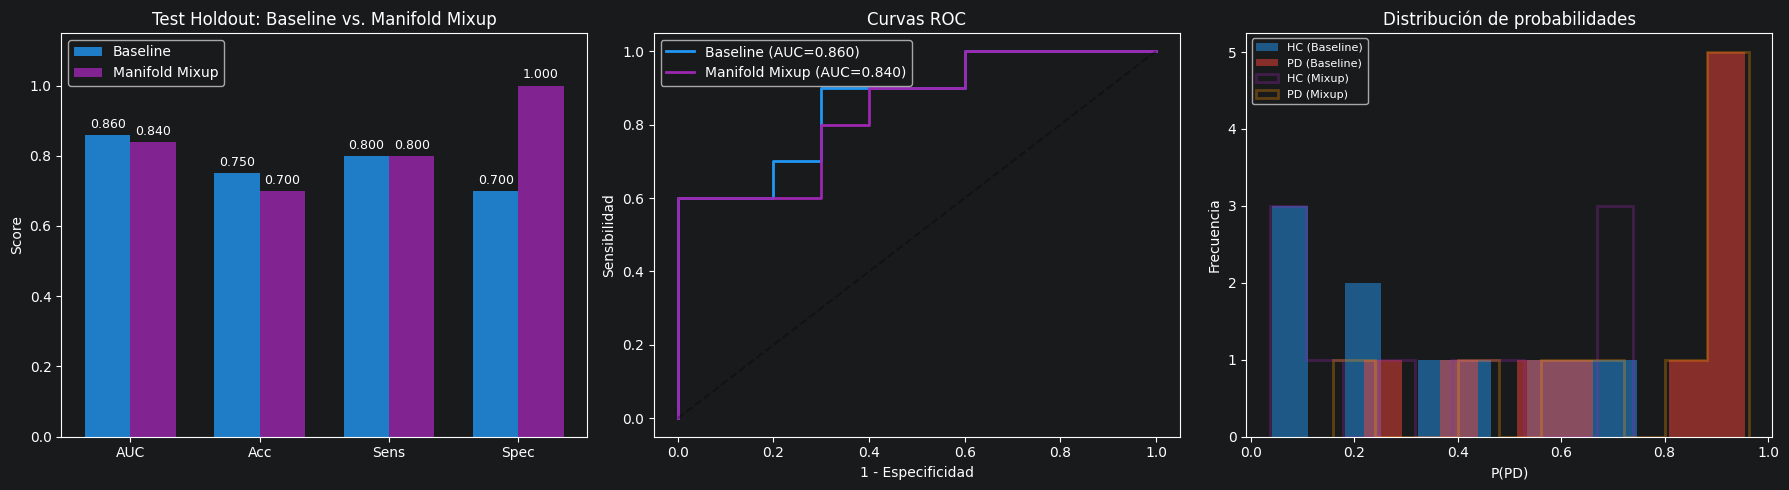

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

N_SEEDS = 5

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === BASELINE ===
bl_test_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train_orig, np.arange(len(labels_train_orig)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(train_ds, test_ds, DEVICE, **bp)
    bl_test_probs.append(y_prob)

bl_prob = np.mean(bl_test_probs, axis=0)
bl_pred = (bl_prob >= 0.5).astype(int)
bl_m = compute_metrics(y_true, bl_prob, bl_pred)

# === MANIFOLD MIXUP ===
rng_mm = np.random.default_rng(RANDOM_STATE)
aug_t, aug_s, aug_labels = manifold_mixup_intraclass(emb_t_train, emb_s_train, labels_train_orig, rng_mm)

emb_t_mm = np.concatenate([emb_t_train, aug_t])
emb_s_mm = np.concatenate([emb_s_train, aug_s])
labels_mm = np.concatenate([labels_train_orig, aug_labels])

mm_test_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_mm, emb_s_mm, labels_mm, np.arange(len(labels_mm)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(train_ds, test_ds, DEVICE, **bp)
    mm_test_probs.append(y_prob)

mm_prob = np.mean(mm_test_probs, axis=0)
mm_pred = (mm_prob >= 0.5).astype(int)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA COMPARATIVA ===
print("=" * 60)
print("COMPARACIÓN FINAL — Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup':>10} {'Δ':>10}")
print(f"  {'─' * 45}")
for name, bl, mm in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {mm - bl:>+10.3f}")

# === GRÁFICOS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Barras
ax = axes[0]
metrics_names = ["AUC", "Acc", "Sens", "Spec"]
x = np.arange(len(metrics_names))
width = 0.35

bars_bl = ax.bar(x - width/2, bl_m, width, label="Baseline", color="#2196F3", alpha=0.8)
bars_mm = ax.bar(x + width/2, mm_m, width, label="Manifold Mixup", color="#9C27B0", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Test Holdout: Baseline vs. Manifold Mixup")
ax.legend()

for bar in bars_bl:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars_mm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)

# 2. Curvas ROC
ax = axes[1]
fpr_bl, tpr_bl, _ = roc_curve(y_true, bl_prob)
fpr_mm, tpr_mm, _ = roc_curve(y_true, mm_prob)

ax.plot(fpr_bl, tpr_bl, color="#2196F3", linewidth=2, label=f"Baseline (AUC={bl_m[0]:.3f})")
ax.plot(fpr_mm, tpr_mm, color="#9C27B0", linewidth=2, label=f"Manifold Mixup (AUC={mm_m[0]:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_title("Curvas ROC")
ax.legend()

# 3. Distribución de probabilidades
ax = axes[2]
ax.hist(bl_prob[y_true == 0], bins=10, alpha=0.5, color="#2196F3", label="HC (Baseline)")
ax.hist(bl_prob[y_true == 1], bins=10, alpha=0.5, color="#F44336", label="PD (Baseline)")
ax.hist(mm_prob[y_true == 0], bins=10, alpha=0.3, color="#9C27B0", edgecolor="#9C27B0",
        linewidth=2, histtype="step", label="HC (Mixup)")
ax.hist(mm_prob[y_true == 1], bins=10, alpha=0.3, color="#FF9800", edgecolor="#FF9800",
        linewidth=2, histtype="step", label="PD (Mixup)")
ax.set_xlabel("P(PD)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()